In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.manifold import TSNE
import os

In [2]:
os.chdir(os.path.expanduser('~'))
os.chdir("/data/cmn_vamal/mwilson")

imaging_data = pd.read_csv("mri_toy_2/mri_toy_dataset/WMH_batch_results/extracted_csvs/combined_hypointensities.csv", index_col = 0)
imaging_data = imaging_data.T
imaging_data.index.name = ("MRI sample label")
imaging_data.columns.name = "Region of interest"
print(imaging_data.head())

Region of interest     1       2       3       4       5       6       7    \
MRI sample label                                                             
I106775             6.1017  7.8771  5.2783  5.5666  5.4999  6.0089  3.2531   
I11606              6.7751  2.1484  1.0498  0.3650  1.2379  0.8028  7.8316   
I11645              8.0823  2.5861  2.3414  2.3419  2.4349  1.1791  5.7671   
I12616              3.4076  2.8684  1.7329  1.7926  1.9224  1.2162  2.5013   
I13722              5.7714  4.5649  1.1272  1.4085  0.6397  0.7794  2.9209   

Region of interest     8       9       10   ...     161      162      163  \
MRI sample label                            ...                             
I106775             3.7568  2.9224  3.5070  ...  1.8182  10.5691  13.3663   
I11606              1.7061  4.8471  0.6751  ...  0.0000   0.0000   1.0101   
I11645              2.3463  5.5872  1.1637  ...  2.8571   0.8197  19.7917   
I12616              1.8810  2.1283  1.3393  ...  4.3478   5.9829  19

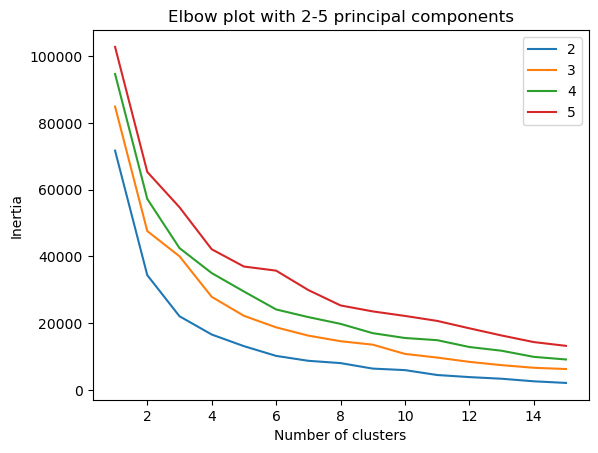

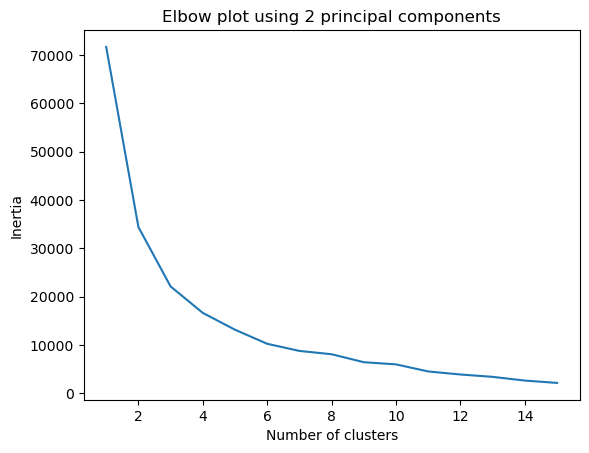

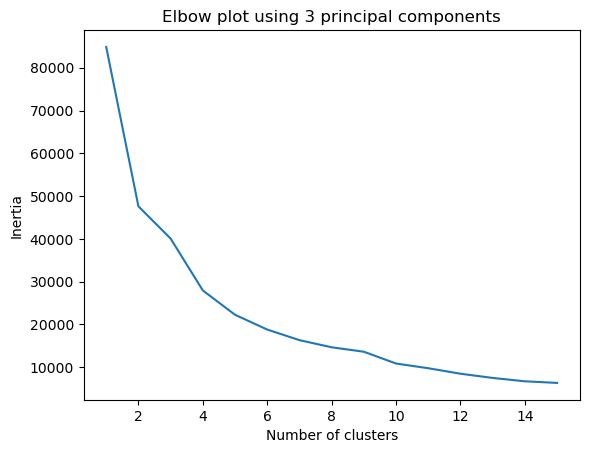

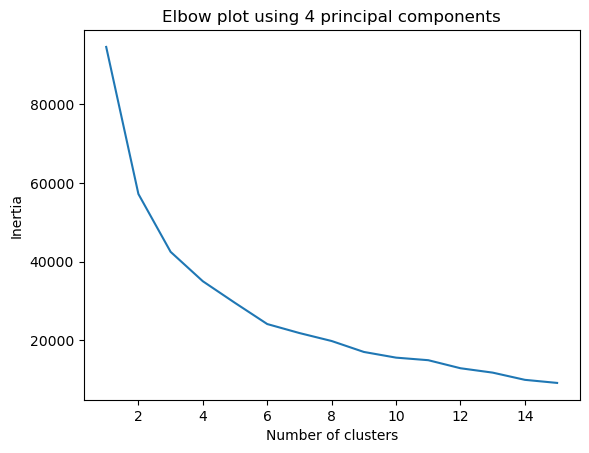

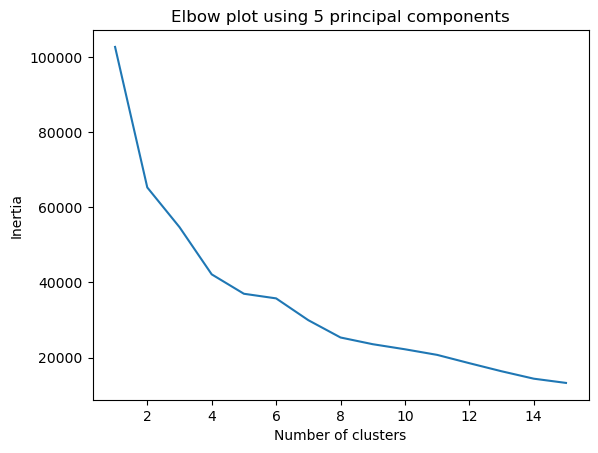

In [28]:
# Elbow plots 

k = np.arange(1,16,1)

for j in range(4):    
    x = []
    for i in range(15):
        pca = PCA(n_components=j+2,random_state=42)
        pca_result = pca.fit_transform(imaging_data)
        kmeans = KMeans(n_clusters=i+1, random_state=0, n_init="auto").fit(pca_result)
        a = (kmeans.inertia_)
        x.append(a)
    plt.plot(k, x, label = j+2)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.legend()
plt.title(f"Elbow plot with 2-5 principal components")
plt.show()

for j in range(4):    
    x = []
    for i in range(15):
        pca = PCA(n_components=j+2,random_state=42)
        pca_result = pca.fit_transform(imaging_data)
        kmeans = KMeans(n_clusters=i+1, random_state=0, n_init="auto").fit(pca_result)
        a = (kmeans.inertia_)
        x.append(a)
    plt.plot(k, x)
    plt.xlabel("Number of clusters")
    plt.ylabel("Inertia")
    plt.title(f"Elbow plot using {j+2} principal components")
    plt.show()

22099.178344192183


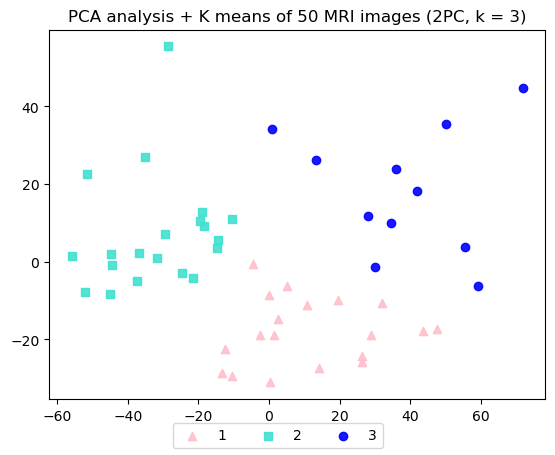

16627.650722213235


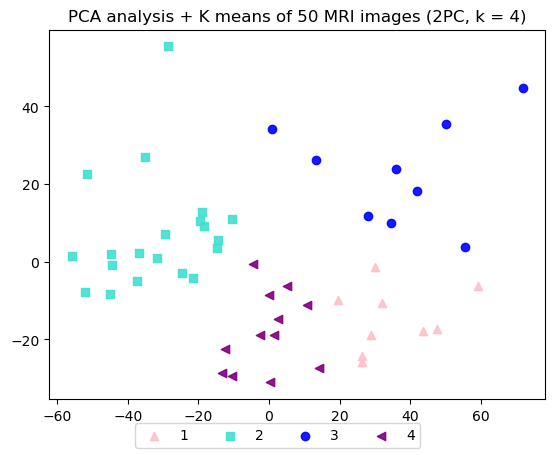

13145.467225616409


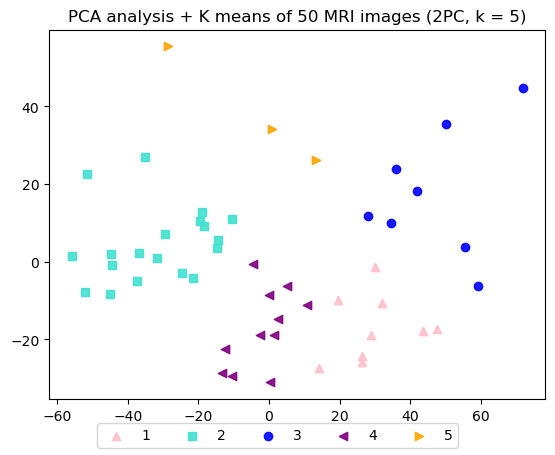

In [6]:
# 2 principal components 

fig, ax = plt.subplots()
pca = PCA(n_components=2,random_state=42)
pca_result = pca.fit_transform(imaging_data)
kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(pca_result)
print(kmeans.inertia_)
y = kmeans.labels_
for l, c, m in zip([0,1,2], ["pink", "turquoise", "blue"], ('^', 's', "o")):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
plt.title("PCA analysis + K means of 50 MRI images (2PC, k = 3)")
labels = [1,2,3]
fig.legend(labels, loc='lower center',ncol=len(labels))
plt.show()

fig, ax = plt.subplots()
pca = PCA(n_components=2,random_state=42)
pca_result = pca.fit_transform(imaging_data)


kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(pca_result)
print(kmeans.inertia_)
y = kmeans.labels_

for l, c, m in zip([0,1,2,3], ["pink", "turquoise", "blue", "purple"], ('^', 's', "o", "<")):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )

plt.title("PCA analysis + K means of 50 MRI images (2PC, k = 4)")
labels = [1,2,3,4]
fig.legend(labels, loc='lower center',ncol=len(labels))

plt.show()

fig, ax = plt.subplots()

pca = PCA(n_components=2,random_state=42)
pca_result = pca.fit_transform(imaging_data)


kmeans = KMeans(n_clusters=5, random_state=0, n_init="auto").fit(pca_result)
print(kmeans.inertia_)
y = kmeans.labels_

for l, c, m in zip([0,1,2,3,4], ["pink", "turquoise", "blue", "purple", "orange"], ('^', 's', "o", "<", ">")):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )

plt.title("PCA analysis + K means of 50 MRI images (2PC, k = 5)")
labels = [1,2,3,4,5]
fig.legend(labels, loc='lower center',ncol=len(labels))

plt.show()

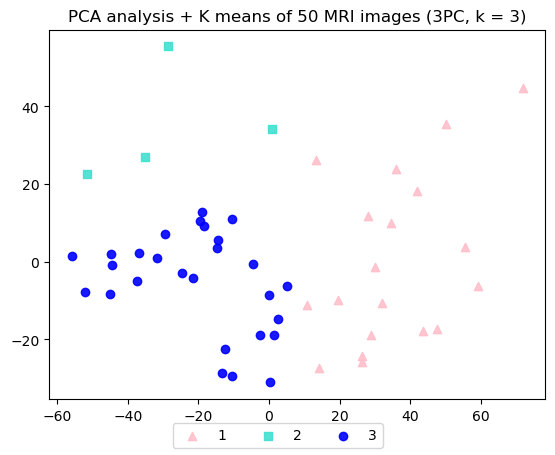

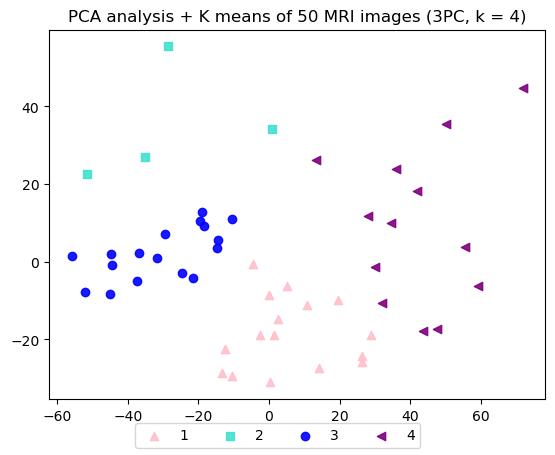

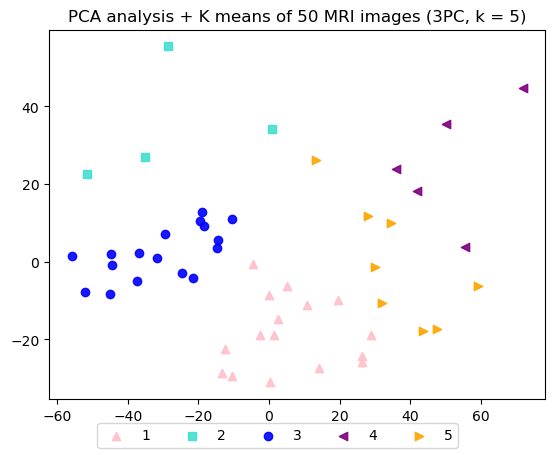

In [4]:
# 3 principal components 

fig, ax = plt.subplots()
pca = PCA(n_components=3,random_state=42)
pca_result = pca.fit_transform(imaging_data)
kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(pca_result)
y = kmeans.labels_
for l, c, m in zip([0,1,2], ["pink", "turquoise", "blue"], ('^', 's', "o")):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
plt.title("PCA analysis + K means of 50 MRI images (3PC, k = 3)")
labels = [1,2,3]
fig.legend(labels, loc='lower center',ncol=len(labels))
plt.show()

fig, ax = plt.subplots()
pca = PCA(n_components=3,random_state=42)
pca_result = pca.fit_transform(imaging_data)
kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(pca_result)
y = kmeans.labels_
for l, c, m in zip([0,1,2,3], ["pink", "turquoise", "blue", "purple"], ('^', 's', "o", "<")):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
plt.title("PCA analysis + K means of 50 MRI images (3PC, k = 4)")
labels = [1,2,3,4]
fig.legend(labels, loc='lower center',ncol=len(labels))
plt.show()

fig, ax = plt.subplots()
pca = PCA(n_components=3,random_state=42)
pca_result = pca.fit_transform(imaging_data)
kmeans = KMeans(n_clusters=5, random_state=0, n_init="auto").fit(pca_result)
y = kmeans.labels_
for l, c, m in zip([0,1,2,3,4], ["pink", "turquoise", "blue", "purple", "orange"], ('^', 's', "o", "<", ">")):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
plt.title("PCA analysis + K means of 50 MRI images (3PC, k = 5)")
labels = [1,2,3,4,5]
fig.legend(labels, loc='lower center',ncol=len(labels))
plt.show()

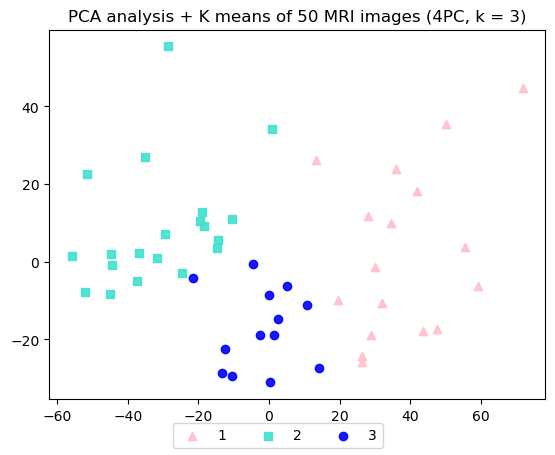

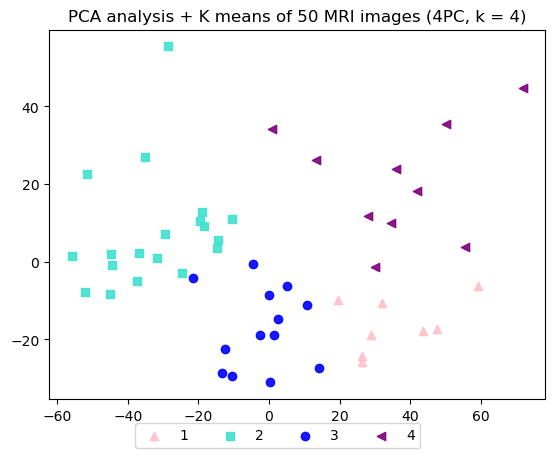

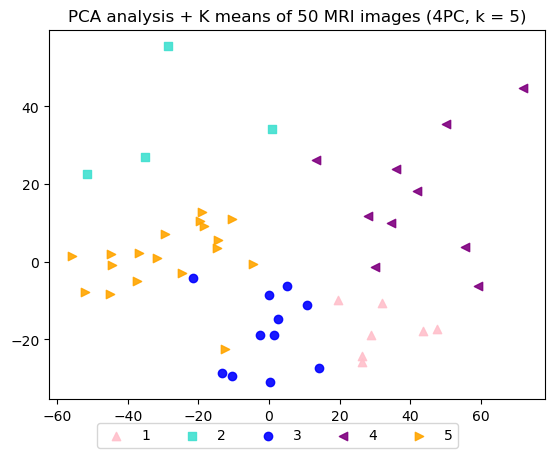

In [5]:
# 4 principal components 

fig, ax = plt.subplots()
pca = PCA(n_components=4,random_state=42)
pca_result = pca.fit_transform(imaging_data)
kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(pca_result)
y = kmeans.labels_
for l, c, m in zip([0,1,2], ["pink", "turquoise", "blue"], ('^', 's', "o")):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
plt.title("PCA analysis + K means of 50 MRI images (4PC, k = 3)")
labels = [1,2,3]
fig.legend(labels, loc='lower center',ncol=len(labels))
plt.show()

fig, ax = plt.subplots()
pca = PCA(n_components=4,random_state=42)
pca_result = pca.fit_transform(imaging_data)
kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(pca_result)
y = kmeans.labels_
for l, c, m in zip([0,1,2,3], ["pink", "turquoise", "blue", "purple"], ('^', 's', "o", "<")):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
plt.title("PCA analysis + K means of 50 MRI images (4PC, k = 4)")
labels = [1,2,3,4]
fig.legend(labels, loc='lower center',ncol=len(labels))
plt.show()

fig, ax = plt.subplots()
pca = PCA(n_components=4,random_state=42)
pca_result = pca.fit_transform(imaging_data)
kmeans = KMeans(n_clusters=5, random_state=0, n_init="auto").fit(pca_result)
y = kmeans.labels_
for l, c, m in zip([0,1,2,3,4], ["pink", "turquoise", "blue", "purple", "orange"], ('^', 's', "o", "<", ">")):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
plt.title("PCA analysis + K means of 50 MRI images (4PC, k = 5)")
labels = [1,2,3,4,5]
fig.legend(labels, loc='lower center',ncol=len(labels))
plt.show()

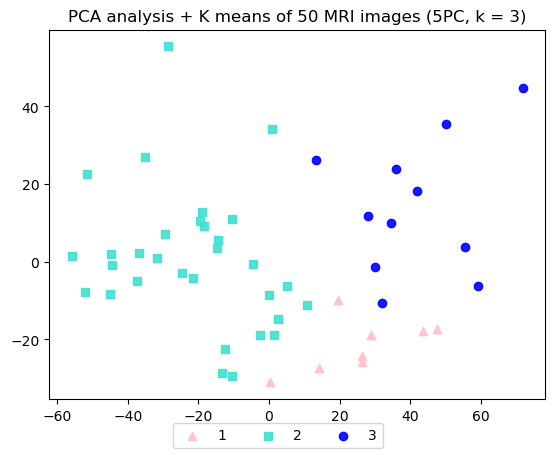

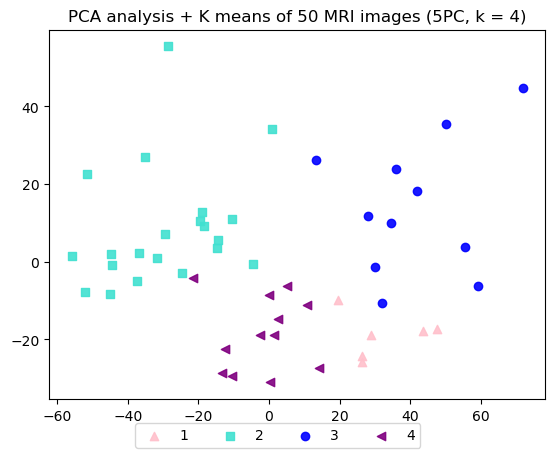

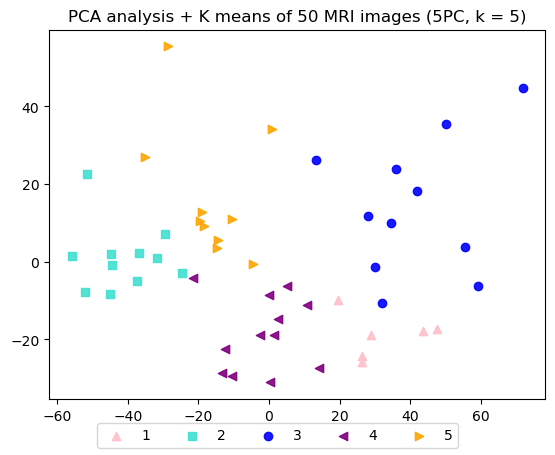

In [20]:
# 5 principal components 

fig, ax = plt.subplots()
pca = PCA(n_components=5,random_state=42)
pca_result = pca.fit_transform(imaging_data)
kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(pca_result)
y = kmeans.labels_
for l, c, m in zip([0,1,2], ["pink", "turquoise", "blue"], ('^', 's', "o")):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
plt.title("PCA analysis + K means of 50 MRI images (5PC, k = 3)")
labels = [1,2,3]
fig.legend(labels, loc='lower center',ncol=len(labels))
plt.show()

fig, ax = plt.subplots()
kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(pca_result)
y = kmeans.labels_
for l, c, m in zip([0,1,2,3], ["pink", "turquoise", "blue", "purple"], ('^', 's', "o", "<")):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
plt.title("PCA analysis + K means of 50 MRI images (5PC, k = 4)")
labels = [1,2,3,4]
fig.legend(labels, loc='lower center',ncol=len(labels))
plt.show()

fig, ax = plt.subplots()
kmeans = KMeans(n_clusters=5, random_state=0, n_init="auto").fit(pca_result)
y = kmeans.labels_
for l, c, m in zip([0,1,2,3,4], ["pink", "turquoise", "blue", "purple", "orange"], ('^', 's', "o", "<", ">")):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
plt.title("PCA analysis + K means of 50 MRI images (5PC, k = 5)")
labels = [1,2,3,4,5]
fig.legend(labels, loc='lower center',ncol=len(labels))
plt.show()

In [6]:
# Adding in TSNE

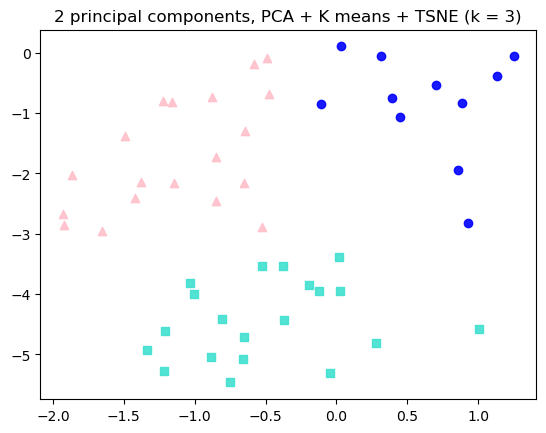

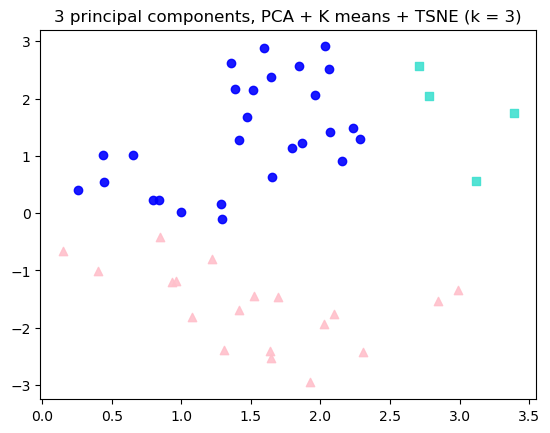

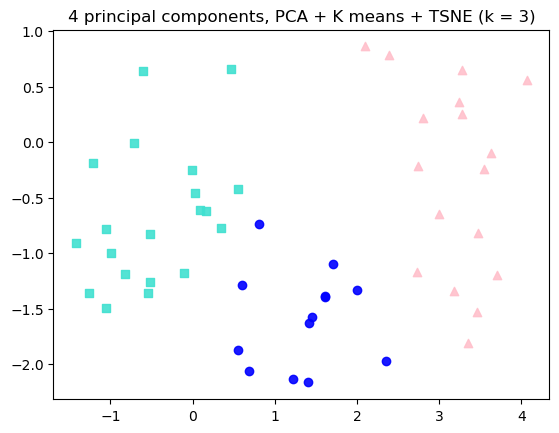

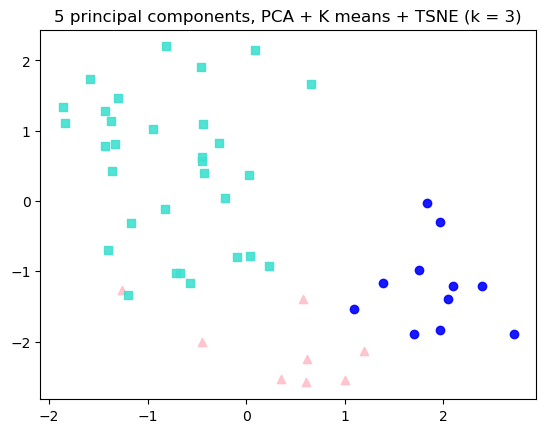

In [14]:
for i in range(2):
    pca = PCA(n_components=i+2,random_state=42)
    pca_result = pca.fit_transform(imaging_data)
    x = TSNE(n_components = 2).fit_transform(pca_result)
    kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(pca_result)
    y = kmeans.labels_    
    fig, ax = plt.subplots() 
    for l, c, m in zip([0,1,2], ["pink", "turquoise", "blue"], ('^', 's', "o")):
        ax.scatter(x[y == l, 0],
                    x[y == l, 1],
                    color=c,
                    label='cluster %s' % l,
                    alpha=0.9,
                    marker=m
                    )
    plt.title(f"{i+2} principal components, PCA + K means + TSNE (k = 3)")

for i in range(4):
    a = i+2
    if a > 3:
        pca = PCA(n_components=a,random_state=42)
        pca_result = pca.fit_transform(imaging_data)
        x = TSNE(n_components = 2, method = "exact").fit_transform(pca_result)
        kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(pca_result)
        y = kmeans.labels_
        fig, ax = plt.subplots() 
        
        for l, c, m in zip([0,1,2], ["pink", "turquoise", "blue"], ('^', 's', "o")):
            ax.scatter(x[y == l, 0],
                        x[y == l, 1],
                        color=c,
                        label='cluster %s' % l,
                        alpha=0.9,
                        marker=m
                        )
        plt.title(f"{a} principal components, PCA + K means + TSNE (k = 3)")

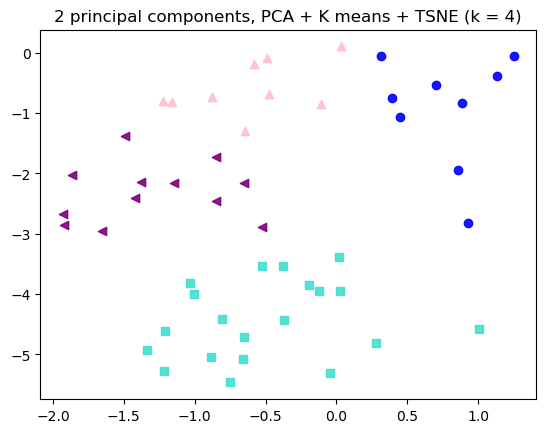

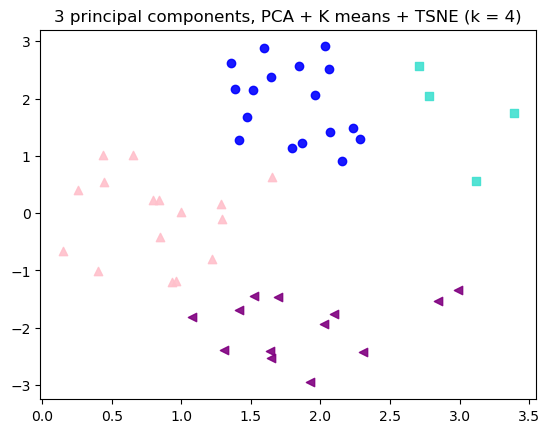

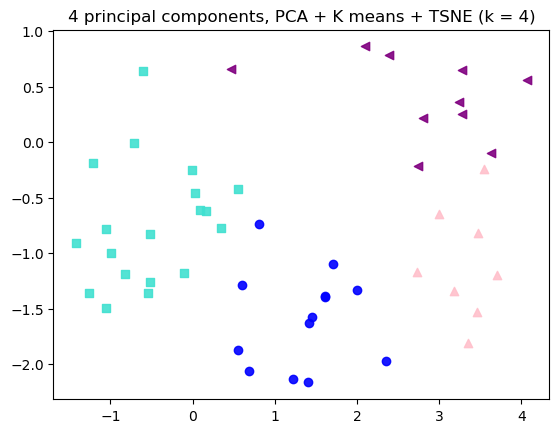

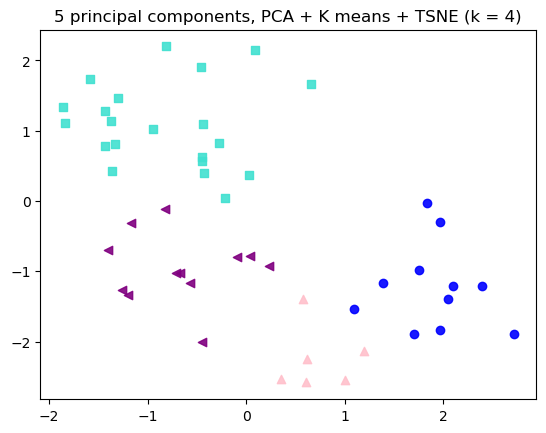

In [19]:
for i in range(2):
    pca = PCA(n_components=i+2,random_state=42)
    pca_result = pca.fit_transform(imaging_data)
    x = TSNE(n_components = 2).fit_transform(pca_result)
    kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(pca_result)
    y = kmeans.labels_    
    fig, ax = plt.subplots() 
    for l, c, m in zip([0,1,2,3], ["pink", "turquoise", "blue", "purple"], ('^', 's', "o", "<")):
        ax.scatter(x[y == l, 0],
                    x[y == l, 1],
                    color=c,
                    label='cluster %s' % l,
                    alpha=0.9,
                    marker=m
                    )
    plt.title(f"{i+2} principal components, PCA + K means + TSNE (k = 4)")

for i in range(4):
    a = i+2
    if a > 3:
        pca = PCA(n_components=a,random_state=42)
        pca_result = pca.fit_transform(imaging_data)
        x = TSNE(n_components = 2, method = "exact").fit_transform(pca_result)
        kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(pca_result)
        y = kmeans.labels_
        fig, ax = plt.subplots() 
        
        for l, c, m in zip([0,1,2,3], ["pink", "turquoise", "blue", "purple"], ('^', 's', "o", "<")):
            ax.scatter(x[y == l, 0],
                        x[y == l, 1],
                        color=c,
                        label='cluster %s' % l,
                        alpha=0.9,
                        marker=m
                        )
        plt.title(f"{a} principal components, PCA + K means + TSNE (k = 4)")


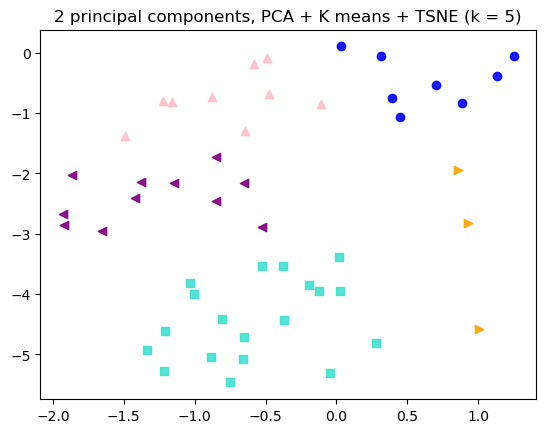

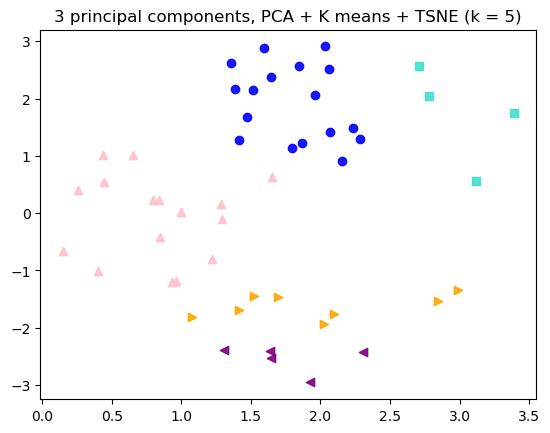

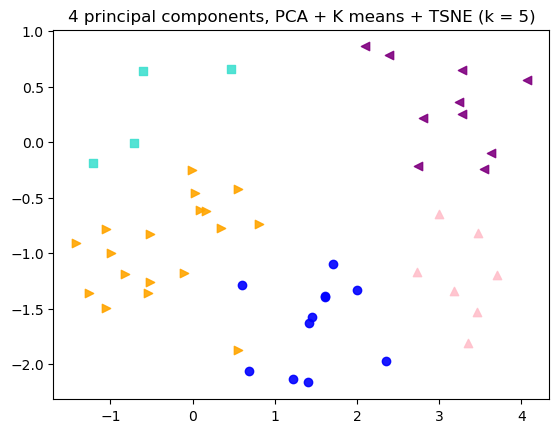

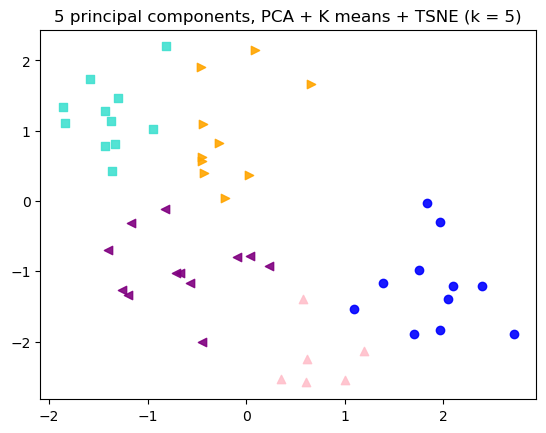

In [18]:
for i in range(2):
    pca = PCA(n_components=i+2,random_state=42)
    pca_result = pca.fit_transform(imaging_data)
    x = TSNE(n_components = 2).fit_transform(pca_result)
    kmeans = KMeans(n_clusters=5, random_state=0, n_init="auto").fit(pca_result)
    y = kmeans.labels_    
    fig, ax = plt.subplots() 
    for l, c, m in zip([0,1,2,3,4], ["pink", "turquoise", "blue", "purple", "orange"], ('^', 's', "o", "<", ">")):
        ax.scatter(x[y == l, 0],
                    x[y == l, 1],
                    color=c,
                    label='cluster %s' % l,
                    alpha=0.9,
                    marker=m
                    )
    plt.title(f"{i+2} principal components, PCA + K means + TSNE (k = 5)")

for i in range(4):
    a = i+2
    if a > 3:
        pca = PCA(n_components=a,random_state=42)
        pca_result = pca.fit_transform(imaging_data)
        x = TSNE(n_components = 2, method = "exact").fit_transform(pca_result)
        kmeans = KMeans(n_clusters=5, random_state=0, n_init="auto").fit(pca_result)
        y = kmeans.labels_
        fig, ax = plt.subplots() 
        
        for l, c, m in zip([0,1,2,3,4], ["pink", "turquoise", "blue", "purple", "orange"], ('^', 's', "o", "<", ">")):
            ax.scatter(x[y == l, 0],
                        x[y == l, 1],
                        color=c,
                        label='cluster %s' % l,
                        alpha=0.9,
                        marker=m
                        )
        plt.title(f"{a} principal components, PCA + K means + TSNE (k = 5)")
